## Library imports

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

# Dataset import - HadISST

In [2]:
# Data acquired from : 
# https://www.metoffice.gov.uk/hadobs/hadisst/data/download.html

hadsst = xr.open_dataset('HadISST_sst.nc')
hadsst

<xarray.Dataset>
Dimensions:    (time: 1838, nv: 2, latitude: 180, longitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 1870-01-16T11:59:59.505615234 ... 2023-0...
  * latitude   (latitude) float32 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float32 -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) float32 ...
    sst        (time, latitude, longitude) float32 ...
Attributes:
    Title:                      Monthly version of HadISST sea surface temper...
    description:                HadISST 1.1 monthly average sea surface tempe...
    institution:                Met Office Hadley Centre
    source:                     HadISST
    reference:                  Rayner, N. A., Parker, D. E., Horton, E. B., ...
    Conventions:                CF-1.0
    history:                    7/4/2023 converted to netcdf from pp format
    supplementary_information:  Updates and supplementary information will be...
    comment:                    Data restrictions: for academic research use ...

## Remove unnecessary data

In [5]:
# Define the latitude and longitude extents : 
latitude_extents = (10,60)
longitude_extents = (0,110)

# In order to provide interpolations that do not return random false NaNs at the edges : 
lat_edges = (latitude_extents[0]-2,latitude_extents[1]+2)
long_edges = (longitude_extents[0]-2,longitude_extents[1]+2)

In [6]:
# Clip the unwanted coordinates : 
ds_sst = hadsst.sel(latitude=slice(lat_edges[1],lat_edges[0]),longitude=slice(-long_edges[1],-long_edges[0]))
ds_sst = ds_sst.sel(time=slice('1870-02','2020-01'))

# Convert celsius to kelvin :
ds_sst = ds_sst + 273.15
ds_sst.sst.attrs['units'] = 'kelvin'

# Comparing file sizes : 
print(f'The original dataset size is : {hadsst.nbytes/1000**2:.2f} MB')
print(f'The sliced dataset size is : {ds_sst.nbytes/1000**2:.2f} MB')

display(ds_sst)

The original dataset size is : 476.44 MB
The sliced dataset size is : 44.35 MB


<xarray.Dataset>
Dimensions:    (time: 1800, latitude: 54, longitude: 114, nv: 2)
Coordinates:
  * time       (time) datetime64[ns] 1870-02-14T23:59:59.340820312 ... 2020-0...
  * latitude   (latitude) float32 61.5 60.5 59.5 58.5 57.5 ... 11.5 10.5 9.5 8.5
  * longitude  (longitude) float32 -111.5 -110.5 -109.5 -108.5 ... -0.5 0.5 1.5
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) float32 304.1 332.1 332.1 ... 5.506e+04 5.509e+04
    sst        (time, latitude, longitude) float32 nan nan nan ... nan nan nan
Attributes:
    Title:                      Monthly version of HadISST sea surface temper...
    description:                HadISST 1.1 monthly average sea surface tempe...
    institution:                Met Office Hadley Centre
    source:                     HadISST
    reference:                  Rayner, N. A., Parker, D. E., Horton, E. B., ...
    Conventions:                CF-1.0
    history:                    7/4/2023 converted to netcdf from pp format
    supplementary_information:  Updates and supplementary information will be...
    comment:                    Data restrictions: for academic research use ...

In [7]:
# Save the sliced dataset :
ds_sst.to_netcdf('sliced_HadISST.nc')

## Visualizations

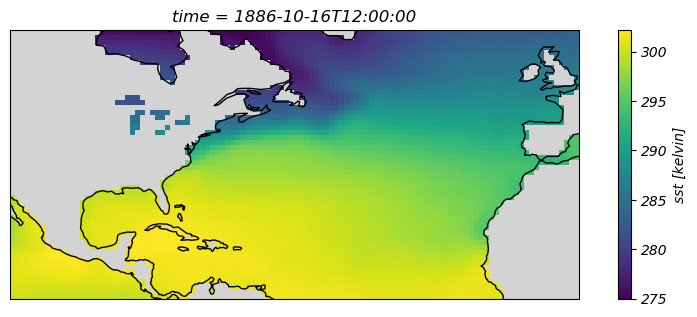

In [8]:
# Quick overview of one timestep :
# General figure geometry :
fig_width = 10
fig_height = (3.5/10)*fig_width
fig = plt.figure(figsize=(fig_width,fig_height))

# Plot the datasets : 
ax = ds_sst.sst[200].plot(
    subplot_kws=dict(
        projection = ccrs.PlateCarree(),facecolor='lightgray',
        transform = ccrs.PlateCarree()
    )
)
ax.axes.coastlines()
plt.show()

## Managing out-of-bounds timestamps

### Pre-1870 hurricanes

In [9]:
sst_pre_1870 = ds_sst.copy()
# Select the bounds : 
min_time_1870 = sst_pre_1870.coords['time'][0].values
max_time_1870 = sst_pre_1870.coords['time'][30*12].values
# Slice the array : 
sst_pre_1870 = sst_pre_1870.sel(time=slice(min_time_1870,max_time_1870))

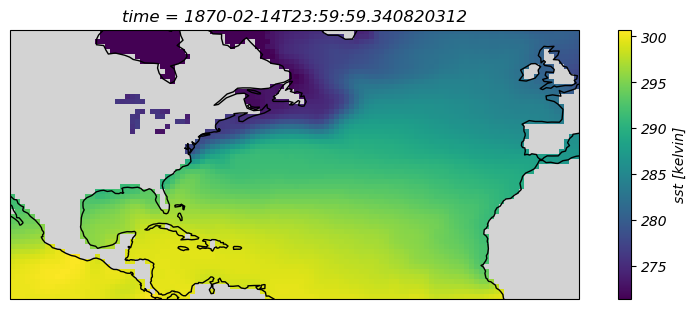

In [10]:
# Fixing bad values before averaging : 

# Find True NaNs and replace with 5s : 
sst_pre_1870_nans = sst_pre_1870.where(~sst_pre_1870.isnull(),5)
# Set the bad values as NaNs :
sst_pre_1870_nans = sst_pre_1870_nans.where(sst_pre_1870_nans>-600,other = np.nan)
# Interpolate only the NaNs with a nearby value :
sst_pre_1870_nans = sst_pre_1870_nans.interpolate_na(dim='longitude',method='nearest')
# Return True NaNs : 
sst_pre_1870_nans = sst_pre_1870_nans.where(sst_pre_1870_nans>50,other = np.nan)

fig_width = 10
fig_height = (3.5/10)*fig_width
fig = plt.figure(figsize=(fig_width,fig_height))

# Plot the datasets : 
ax = sst_pre_1870_nans.sst[0].plot(
    subplot_kws=dict(
        projection = ccrs.PlateCarree(),facecolor='lightgray',
        transform = ccrs.PlateCarree()
    )
)
ax.axes.coastlines()
plt.show()

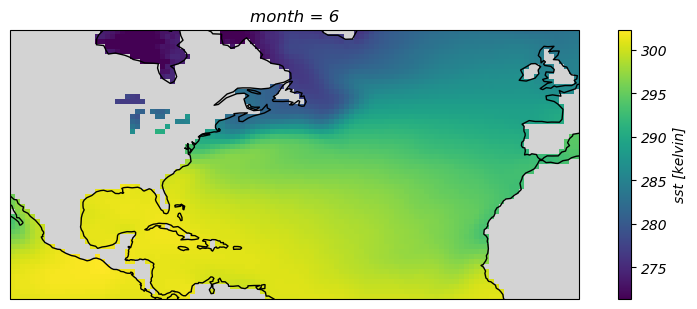

In [11]:
# Grouping by month : 
sst_pre_1870_final = sst_pre_1870_nans.groupby('time.month').mean('time')

# Month to plot (from 1 to 12): 
mnth = 6

# Plot :
# Layout
fig_width = 10
fig_height = (3.5/10)*fig_width
fig = plt.figure(figsize=(fig_width,fig_height))
# Data 
ax = sst_pre_1870_final.sst[mnth-1].plot(
    subplot_kws=dict(
        projection = ccrs.PlateCarree(),facecolor='lightgray',
        transform = ccrs.PlateCarree()
    )
)
ax.axes.coastlines()

In [12]:
# Save the dataset :
sst_pre_1870_final.to_netcdf('sst_pre_1870.nc')

### Post 2020-01 hurricanes

In [13]:
sst_post_2020 = ds_sst.copy()
# Select the bounds : 
min_time_2020 = sst_post_2020.coords['time'][-1].values
max_time_2020 = sst_post_2020.coords['time'][-30*12-1].values
# Slice the array : 
sst_post_2020 = sst_post_2020.sel(time=slice(max_time_2020,min_time_2020))

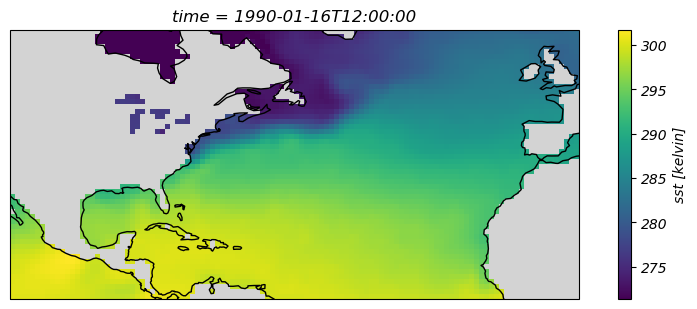

In [14]:
# Fixing bad values before averaging : 

# Find True NaNs and replace with 5s : 
sst_post_2020_nans = sst_post_2020.where(~sst_post_2020.isnull(),5)
# Set the bad values as NaNs :
sst_post_2020_nans = sst_post_2020_nans.where(sst_post_2020_nans>-600,other = np.nan)
# Interpolate only the NaNs with a nearby value :
sst_post_2020_nans = sst_post_2020_nans.interpolate_na(dim='longitude',method='nearest')
# Return True NaNs : 
sst_post_2020_nans = sst_post_2020_nans.where(sst_post_2020_nans>50,other = np.nan)

fig_width = 10
fig_height = (3.5/10)*fig_width
fig = plt.figure(figsize=(fig_width,fig_height))

# Plot the datasets : 
ax = sst_post_2020_nans.sst[0].plot(
    subplot_kws=dict(
        projection = ccrs.PlateCarree(),facecolor='lightgray',
        transform = ccrs.PlateCarree()
    )
)
ax.axes.coastlines()
plt.show()

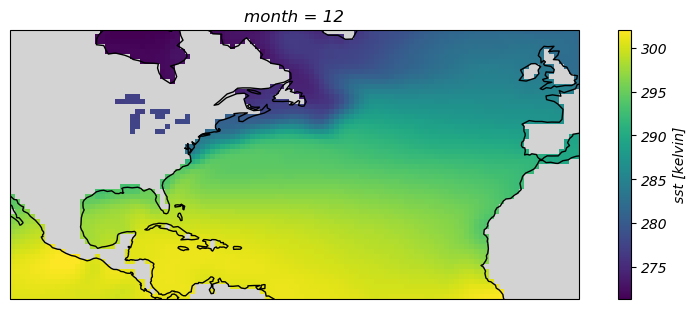

In [15]:
# Grouping by month : 
sst_post_2020_final = sst_post_2020_nans.groupby('time.month').mean('time')

# Month to plot (from 1 to 12): 
mnth = 12

# Plot :
# Layout
fig_width = 10
fig_height = (3.5/10)*fig_width
fig = plt.figure(figsize=(fig_width,fig_height))
# Data 
ax = sst_post_2020_final.sst[mnth-1].plot(
    subplot_kws=dict(
        projection = ccrs.PlateCarree(),facecolor='lightgray',
        transform = ccrs.PlateCarree()
    )
)
ax.axes.coastlines()

In [16]:
# Save the dataset :
sst_post_2020_final.to_netcdf('sst_post_2020.nc')

## Validations and display on how to select a specific interpolated value : 

In [17]:
# Selecting a coordinate at a certain time : 
coords = ([26.0],[-31.0])
time = ['1886-10-16 12']
"""
coords = (latitude,longitude)

Note : xarray interpolates in all 3 dimensions (coords and time)
"""
# Interpolating and extracting numeric value : 
temperature = ds_sst.interp(latitude =coords[0], longitude =coords[1], time = time).sst.item()
print(temperature)

export = False
# Exporting to a dataframe / a tabular editor :
if export == True : 
    df = ds_sst.sst[0].to_dataframe()
    df.to_csv('df.csv')
    display(df)

297.9675827026367


# Dataset import - NOAA Air temperature

In [3]:
# Downloaded from : 
#https://psl.noaa.gov/data/gridded/data.20thC_ReanV3.html

# Dataset taken from the NOAA/CIRES/DOE 20th Century Reanalysis (V3)
air_temps = xr.open_dataset('datasets/air_mon_mean_NOAA_CIRES_DOE_RV3.nc')
air_temps

<xarray.Dataset>
Dimensions:    (level: 28, lat: 181, lon: 360, time: 2160, nbnds: 2)
Coordinates:
  * level      (level) float32 1e+03 975.0 950.0 925.0 ... 20.0 10.0 5.0 1.0
  * lat        (lat) float32 -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon        (lon) float32 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * time       (time) datetime64[ns] 1836-01-01 1836-02-01 ... 2015-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 ...
    air        (time, level, lat, lon) float32 ...
Attributes: (12/24)
    Conventions:               CF-1.2
    title:                     Monthly NOAA/CIRES/DOE 20th Century Reanalysis V3
    comments:                  Data are from \nNOAA/CIRES/DOE 20th Century Re...
    platform:                  Model
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    license:                   These data are available free of charge under ...
    ...                        ...
    citation1:                 Slivinski, L. C, G. P. Compo, J. S. Whitaker, ...
    References:                https://www.psl.noaa.gov/data/gridded/data.20t...
    creator_name:              NOAA/PSL
    institution:               NOAA Physical Sciences Laboratory & CU/CIRES \...
    contact:                   psl.data@noaa.gov
    citation:                  Compo,G.P. <https://www.psl.noaa.gov/people/gi...

## Remove unecessary data

In [5]:
# Define the latitude and longitude extents : 
latitude_extents = (10,60)
longitude_extents = (0,110)

# In order to provide interpolations that do not return random false NaNs at the edges : 
lat_edges = (latitude_extents[0]-2,latitude_extents[1]+2)
long_edges = (longitude_extents[0]-2,longitude_extents[1]+2)

In [6]:
# Clip the unwanted coordinates : 
# Note : the NOAA datasets uses 0 to 360, where 0 is set as Greenwhich (england) and 360 corresponds to a full circle roundtrip.
ds_air = air_temps.sel(lat=slice(lat_edges[0],lat_edges[1]),lon=slice(-long_edges[1]+360,-long_edges[0]+360))
ds_air = ds_air.sel(time=slice('1851-05','2015-12'))
ds_air = ds_air.sel(level ='100')
ds_air = ds_air.drop('level') # We don't need this variable anymore, as we only wish to check at 100 mb.

# Comparing file sizes : 
print(f'The original dataset size is : {air_temps.nbytes/1000**2:.2f} MB')
print(f'The sliced dataset size is : {ds_air.nbytes/1000**2:.2f} MB')

display(ds_air)

The original dataset size is : 15763.56 MB
The sliced dataset size is : 48.74 MB


<xarray.Dataset>
Dimensions:    (lat: 55, lon: 112, time: 1976, nbnds: 2)
Coordinates:
  * lat        (lat) float32 8.0 9.0 10.0 11.0 12.0 ... 58.0 59.0 60.0 61.0 62.0
  * lon        (lon) float32 248.0 249.0 250.0 251.0 ... 356.0 357.0 358.0 359.0
  * time       (time) datetime64[ns] 1851-05-01 1851-06-01 ... 2015-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 ...
    air        (time, lat, lon) float32 ...
Attributes: (12/24)
    Conventions:               CF-1.2
    title:                     Monthly NOAA/CIRES/DOE 20th Century Reanalysis V3
    comments:                  Data are from \nNOAA/CIRES/DOE 20th Century Re...
    platform:                  Model
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    license:                   These data are available free of charge under ...
    ...                        ...
    citation1:                 Slivinski, L. C, G. P. Compo, J. S. Whitaker, ...
    References:                https://www.psl.noaa.gov/data/gridded/data.20t...
    creator_name:              NOAA/PSL
    institution:               NOAA Physical Sciences Laboratory & CU/CIRES \...
    contact:                   psl.data@noaa.gov
    citation:                  Compo,G.P. <https://www.psl.noaa.gov/people/gi...

# Validate the shaved areas correspond to expectations

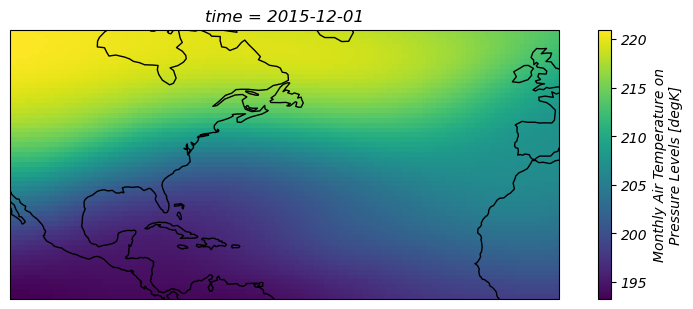

In [8]:
# Quick overview of one timestep :
# General figure geometry :
fig_width = 10
fig_height = (3.5/10)*fig_width
fig = plt.figure(figsize=(fig_width,fig_height))

# Plot a sample of the datasets : 
ax = ds_air.air[1975].plot(
    subplot_kws=dict(
        projection = ccrs.PlateCarree(),facecolor='lightgray',
        transform = ccrs.PlateCarree()
    )
)
ax.axes.coastlines()
plt.show()

In [9]:
ds_air.to_netcdf('air_mon_temp_sliced.nc')

# Dataset import - NCEP Reanalysis V2 (covering 2015 and more recent)

In [10]:
# Downloaded from : 
#https://psl.noaa.gov/data/gridded

# Dataset taken from the NOAA/CIRES/DOE 20th Century Reanalysis (V3)
air_temps2 = xr.open_dataset('datasets/air_mon_mean_NCEP_Reanalysis_V2.nc')
air_temps2

<xarray.Dataset>
Dimensions:    (level: 17, lat: 73, lon: 144, time: 533, nbnds: 2)
Coordinates:
  * level      (level) float32 1e+03 925.0 850.0 700.0 ... 50.0 30.0 20.0 10.0
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2023-05-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] ...
    air        (time, level, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

## Remove unecessary data

In [51]:
# Define the latitude and longitude extents : 
latitude_extents = (10,60)
longitude_extents = (0,110)

# In order to provide interpolations that do not return random false NaNs at the edges : 
lat_edges = (latitude_extents[0]-2,latitude_extents[1]+2)
long_edges = (longitude_extents[0]-2,longitude_extents[1]+2)

In [70]:
# Clip the unwanted coordinates : 
# Note : the NOAA datasets uses 0 to 360, where 0 is set as Greenwhich (england) and 360 corresponds to a full circle roundtrip.
ds_air2 = air_temps2.sel(lat=slice(lat_edges[1],lat_edges[0]),lon=slice(-long_edges[1]+360,-long_edges[0]+360))
ds_air2 = ds_air2.sel(time=slice('2015-12','2021-01'))
ds_air2 = ds_air2.sel(level ='100')
ds_air2 = ds_air2.drop('level') # We don't need this variable anymore, as we only wish to check at 100 mb.

# Comparing file sizes : 
print(f'The original dataset size is : {air_temps2.nbytes/1000**2:.2f} MB')
print(f'The sliced dataset size is : {ds_air2.nbytes/1000**2:.2f} MB')

display(ds_air2)

The original dataset size is : 381.01 MB
The sliced dataset size is : 0.23 MB


<xarray.Dataset>
Dimensions:    (lat: 21, lon: 44, time: 62, nbnds: 2)
Coordinates:
  * lat        (lat) float32 60.0 57.5 55.0 52.5 50.0 ... 17.5 15.0 12.5 10.0
  * lon        (lon) float32 250.0 252.5 255.0 257.5 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 2015-12-01 2016-01-01 ... 2021-01-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] ...
    air        (time, lat, lon) float32 ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

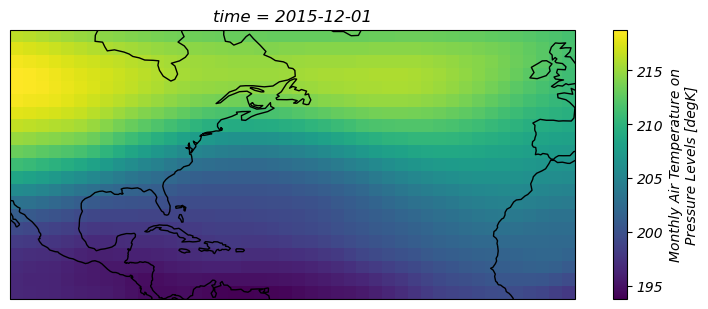

In [71]:
# Quick overview of one timestep :
# General figure geometry :
fig_width = 10
fig_height = (3.5/10)*fig_width
fig = plt.figure(figsize=(fig_width,fig_height))

# Plot a sample of the datasets : 
ax = ds_air2.air[0].plot(
    subplot_kws=dict(
        projection = ccrs.PlateCarree(),facecolor='lightgray',
        transform = ccrs.PlateCarree()
    )
)
ax.axes.coastlines()
#ax.axes.get_xlabel()
plt.show()

In [72]:
ds_air2.to_netcdf('air_mon_temp_sliced_2015-2021.nc')